# **Producto Integrador de Aprendizaje**
## Mejora y Segmentación de Imágenes Médicas para Diagnóstico Asistido por Computadora

Este notebook reúne el trabajo de todo el equipo, dividido en tres bloques: histograma y ecualización, operaciones aritméticas/lógicas y filtros, y segmentación con Transformada de Fourier. Cada bloque conserva las explicaciones de quien lo desarrolló.

## **3.1 Carga de la imagen, análisis y ecualización del histograma**

_Pendiente: integrar aquí el notebook de [Nombre Persona 1] con la carga de la imagen, el histograma original, el histograma ecualizado y su comparación._

## **3.2 Operaciones aritméticas y lógicas, y filtros espaciales**

- Operaciones aritméticas y lógicas

  - Resta entre una imagen original y una imagen suavizada para resaltar bordes (imagen original - imagen suavizada).

  - Aplicación de máscaras binarias usando operaciones lógicas (AND, OR) para enfocar zonas específicas.

## **Líbrerias**

Inicializar las librerias a ejecutar para el ejercicio

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

## **Carga de imagen**

Para el desarrollo de esta etapa del proyecto se utilizó una imagen médica cargada manualmente por el usuario mediante la herramienta `files.upload()` de Google Colab. Posteriormente, la imagen fue leída utilizando la librería OpenCV con la función `cv2.imread()`.

Debido a que la mayoría de las técnicas de procesamiento digital empleadas en este ejercicio trabajan sobre un único canal de intensidad, la imagen fue convertida a escala de grises mediante la función `cv2.cvtColor()`. Esta transformación simplifica el procesamiento y permite analizar únicamente la información de luminancia presente en la imagen.

Imagen utilizada:

[Chest_x-ray_plain_film_normal.jpg](https://commons.wikimedia.org/wiki/File:Chest_x-ray_plain_film_normal.jpg)

Saving Chest_x-ray_plain_film_normal.jpg to Chest_x-ray_plain_film_normal.jpg
Imagen cargada correctamente


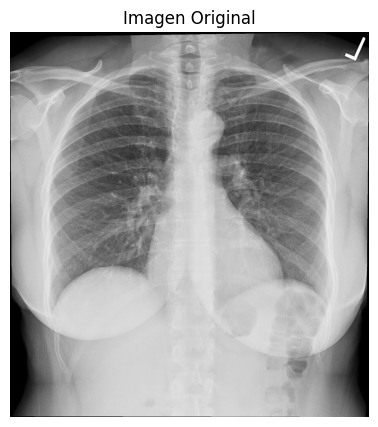

In [ ]:
uploaded = files.upload()
fname = next(iter(uploaded.keys()))
img = cv2.imread(fname)
if img is None:
    print("Error al cargar la imagen")
else:
    print("Imagen cargada correctamente")
# Convertir a escala de grises
gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
# Mostrar imagen original
plt.figure(figsize=(5,5))
plt.imshow(gris, cmap='gray')
plt.title("Imagen Original")
plt.axis('off')
plt.show()

## **Filtro Pasa-Bajo**

Los filtros pasa-bajo son técnicas de suavizado utilizadas para reducir ruido y pequeñas variaciones de intensidad presentes en una imagen. Estos filtros conservan las estructuras generales mientras eliminan detalles de alta frecuencia.

En este proyecto se aplicaron dos filtros:

***Filtro de Media***

El filtro de `media` reemplaza cada píxel por el promedio de los valores de sus vecinos dentro de una ventana determinada. Este procedimiento reduce el ruido, aunque también puede producir una ligera pérdida de nitidez en los bordes.

***Filtro Gaussiano***

El filtro `gauss` gaussiano realiza un suavizado ponderado utilizando una distribución gaussiana. A diferencia del filtro de media, asigna mayor importancia a los píxeles cercanos al centro de la ventana, logrando una reducción de ruido más natural y preservando mejor las estructuras anatómicas de la imagen.

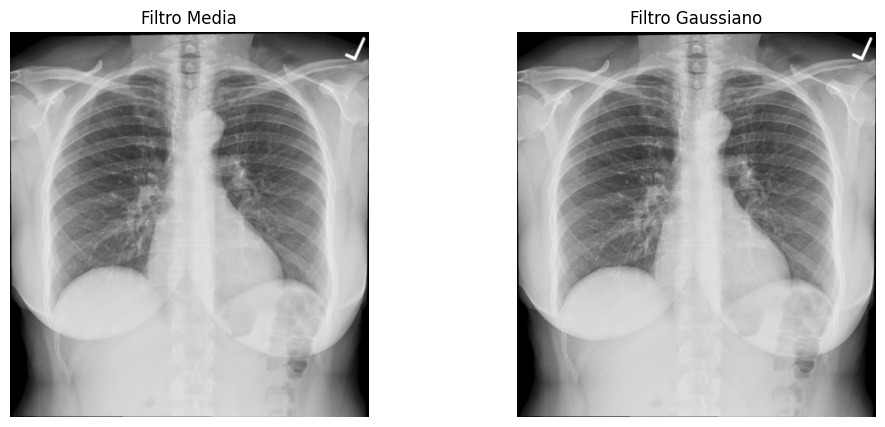

In [ ]:
media = cv2.blur(gris, (5,5))
gauss = cv2.GaussianBlur(gris, (5,5), 0)
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.imshow(media, cmap='gray')
plt.title("Filtro Media")
plt.axis('off')
plt.subplot(1,2,2)
plt.imshow(gauss, cmap='gray')
plt.title("Filtro Gaussiano")
plt.axis('off')
plt.show()

## **Operación Aritmética: Resta**

Las operaciones aritméticas permiten combinar o comparar imágenes mediante operaciones matemáticas. En este ejercicio se realizó una `resta` entre la imagen original y una versión suavizada mediante filtro gaussiano.

La operación:

***Imagen original − Imagen suavizada***

Permite resaltar las diferencias entre ambas imágenes. Debido a que la imagen suavizada contiene menos detalles finos, la resta destaca principalmente los bordes y cambios bruscos de intensidad, facilitando la identificación de estructuras anatómicas relevantes.

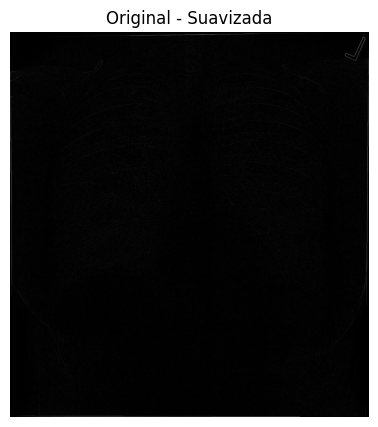

In [ ]:
resta = cv2.subtract(gris, gauss)
plt.figure(figsize=(5,5))
plt.imshow(resta, cmap='gray')
plt.title("Original - Suavizada")
plt.axis('off')
plt.show()

## **Operación Lógicas**

Las operaciones lógicas son herramientas fundamentales en el procesamiento digital de imágenes, especialmente en tareas de segmentación y selección de regiones de interés.

Para aplicar estas operaciones se generó previamente una máscara binaria mediante umbralización. En esta máscara, los píxeles se clasifican en dos grupos: fondo y objeto.

***Operación AND***

La operación lógica `AND` conserva únicamente los píxeles que pertenecen a las regiones seleccionadas por la máscara. Esta técnica permite aislar estructuras específicas de la imagen para su análisis.

***Operación OR***

La operación lógica `OR` combina la información de la imagen y la máscara, resaltando las regiones seleccionadas. Esta operación es útil para visualizar de manera más evidente las zonas de interés dentro de la imagen médica.

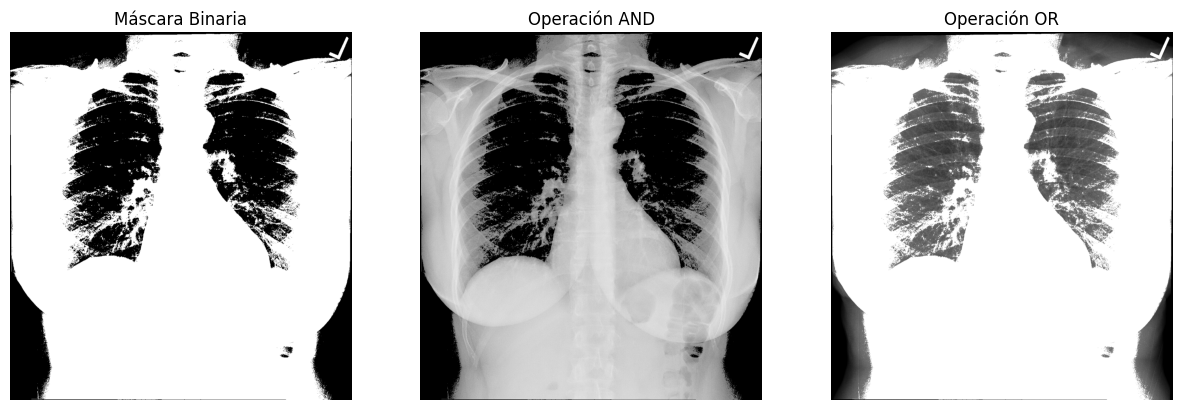

In [ ]:
_, mascara = cv2.threshold(
    gris,
    120,
    255,
    cv2.THRESH_BINARY
)
resultado_and = cv2.bitwise_and(
    gris,
    gris,
    mask=mascara
)
resultado_or = cv2.bitwise_or(
    gris,
    mascara
)
plt.figure(figsize=(15,5))
plt.subplot(1,3,1)
plt.imshow(mascara, cmap='gray')
plt.title("Máscara Binaria")
plt.axis('off')
plt.subplot(1,3,2)
plt.imshow(resultado_and, cmap='gray')
plt.title("Operación AND")
plt.axis('off')
plt.subplot(1,3,3)
plt.imshow(resultado_or, cmap='gray')
plt.title("Operación OR")
plt.axis('off')
plt.show()

## **Filtro Pasa-Alto**

Los filtros pasa-alto se utilizan para resaltar detalles finos y detectar bordes dentro de una imagen. Estos filtros enfatizan las variaciones rápidas de intensidad, las cuales suelen corresponder a contornos y límites entre estructuras anatómicas.

***Filtro Sobel***

El operador `Sobel` calcula el gradiente de intensidad en las direcciones horizontal y vertical. Su resultado permite identificar bordes y contornos presentes en la imagen, proporcionando información sobre la forma de las estructuras anatómicas.

***Filtro Laplaciano***

El operador `Laplaciano` utiliza derivadas de segundo orden para detectar cambios bruscos de intensidad en todas las direcciones. Este filtro es especialmente útil para resaltar bordes y detalles finos, aunque también puede ser más sensible al ruido que otros métodos de detección de contornos.

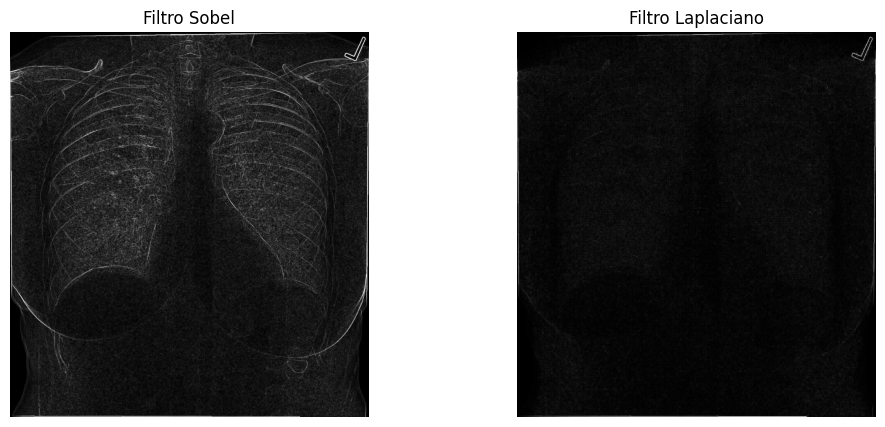

Proceso finalizado correctamente


In [ ]:
sobel_x = cv2.Sobel(
    gris,
    cv2.CV_64F,
    1,
    0,
    ksize=3
)
sobel_y = cv2.Sobel(
    gris,
    cv2.CV_64F,
    0,
    1,
    ksize=3
)
sobel = cv2.magnitude(
    sobel_x,
    sobel_y
)
sobel = cv2.convertScaleAbs(sobel)

laplaciano = cv2.Laplacian(
    gris,
    cv2.CV_64F
)
laplaciano = cv2.convertScaleAbs(
    laplaciano
)
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.imshow(sobel, cmap='gray')
plt.title("Filtro Sobel")
plt.axis('off')
plt.subplot(1,2,2)
plt.imshow(laplaciano, cmap='gray')
plt.title("Filtro Laplaciano")
plt.axis('off')
plt.show()
print("Proceso finalizado correctamente")

***Restultados obtenidos - Análisis de resultados***

Al aplicar los filtros pasa-bajo se observó que tanto el filtro de media como el gaussiano lograron reducir parte del ruido presente en la radiografía. Sin embargo, el filtro gaussiano conservó mejor los contornos de las estructuras anatómicas, por lo que la imagen resultó más suave sin perder demasiados detalles importantes.

En la operación de resta entre la imagen original y la imagen suavizada se logró resaltar principalmente las zonas donde existían cambios de intensidad. Esto permitió destacar algunos bordes y detalles anatómicos que no eran tan evidentes en la imagen original, facilitando su observación.

Respecto a las operaciones lógicas, la máscara binaria permitió seleccionar regiones específicas de la imagen. La operación AND conservó únicamente las áreas definidas por la máscara, mientras que la operación OR resaltó dichas regiones dentro de la imagen. Estas operaciones mostraron cómo es posible enfocar el análisis en zonas de interés mediante el uso de máscaras.

Por último, se aplicaron los filtros Sobel y Laplaciano para la detección de bordes. En los resultados obtenidos se pudo observar que el filtro Sobel resaltó de forma más clara las costillas, clavículas y contornos de los pulmones, permitiendo identificar mejor las estructuras anatómicas presentes en la radiografía. En cambio, el filtro Laplaciano también detectó bordes, pero estos fueron menos visibles y con menor contraste que los obtenidos con Sobel.

En general, las técnicas aplicadas permitieron comprender cómo diferentes métodos de procesamiento digital pueden mejorar la visualización de una imagen médica. De todos los filtros utilizados para detección de bordes, el operador Sobel fue el que proporcionó los resultados más claros y fáciles de interpretar en esta radiografía.

## **3.3 Segmentación por umbral y Transformada de Fourier**

Esta sección aplica segmentación por umbral fijo y adaptativo con un control deslizante interactivo, además del análisis en el dominio de la frecuencia mediante la Transformada de Fourier.

In [ ]:
# =====================================================================
# SECCIÓN 3.3: SEGMENTACIÓN POR UMBRAL Y TRANSFORMADA DE FOURIER
# =====================================================================


from ipywidgets import interact, IntSlider


def segmentacion_interactiva(valor_umbral):
    """
    Función interactiva que aplica umbralización fija global y adaptativa,
    permitiendo ajustar el umbral en tiempo real con un slider.
    """
    # 1. Aplicación de Umbral Fijo Global (Usa el valor dinámico del slider)
    _, thresh_fijo = cv2.threshold(gris, valor_umbral, 255, cv2.THRESH_BINARY)

    # 2. Aplicación de Umbral Adaptativo Local (Ponderación Gaussiana)
    thresh_adapt = cv2.adaptiveThreshold(
        gris, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY, 11, 2
    )

    # Despliegue de los resultados para comparación visual directa
    plt.figure(figsize=(14, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(gris, cmap='gray')
    plt.title("Radiografía Original")
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(thresh_fijo, cmap='gray')
    plt.title(f"Umbral Fijo Global (T={valor_umbral})")
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(thresh_adapt, cmap='gray')
    plt.title("Umbral Adaptativo Gaussiano")
    plt.axis('off')

    plt.tight_layout()
    plt.show()

# Ejecución del control interactivo en Colab
print("Ajuste el valor de 'valor_umbral' para interactuar con la segmentación:")
interact(segmentacion_interactiva, valor_umbral=IntSlider(min=0, max=255, step=1, value=125));


# =====================================================================
# ANÁLISIS EN FRECUENCIA (TRANSFORMADA DE FOURIER 2D)
# =====================================================================

# 1. Obtener la FFT 2D y desplazar las bajas frecuencias al centro
f_transform = np.fft.fft2(gris)
f_shift = np.fft.fftshift(f_transform)

# 2. Calcular el espectro de magnitud en escala logarítmica para visualización
espectro_magnitud = 20 * np.log(np.abs(f_shift) + 1)

# 3. Diseño del Filtro Pasa-Bajas Ideal (Máscara circular)
filas, columnas = gris.shape
centro_f, centro_c = filas // 2, columnas // 2
radio_corte = 40  # Radio en píxeles para atenuar alta frecuencia

# Creamos la máscara binaria del tamaño de la imagen
mascara_pasa_bajas = np.zeros((filas, columnas), np.uint8)
cv2.circle(mascara_pasa_bajas, (centro_c, centro_f), radio_corte, 1, -1)

# 4. Multiplicación del espectro por la máscara circular (Filtrado)
f_shift_filtrado = f_shift * mascara_pasa_bajas

# 5. Deshacer el centrado (shift) y calcular la Transformada Inversa (IFFT)
f_ishift = np.fft.ifftshift(f_shift_filtrado)
img_reconstruida = np.fft.ifft2(f_ishift)
img_reconstruida = np.abs(img_reconstruida)

# =====================================================================
# VISUALIZACIÓN DE RESULTADOS DE FOURIER
# =====================================================================
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(gris, cmap='gray')
plt.title("Original (Espacio)")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(espectro_magnitud, cmap='gray')
plt.title("Espectro de Magnitud FFT 2D")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(img_reconstruida, cmap='gray')
plt.title(f"Reconstruida (Pasa-Bajas, R={radio_corte})")
plt.axis('off')

plt.tight_layout()
plt.show()

print("Etapa de procesamiento en frecuencia concluida.")